In [2]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df_raw = pd.read_csv(url)

# Recreate the sklearn-style columns
df = pd.DataFrame()
df['MedInc']      = df_raw['median_income']
df['HouseAge']    = df_raw['housing_median_age']
df['AveRooms']    = df_raw['total_rooms']    / df_raw['households']
df['AveBedrms']   = df_raw['total_bedrooms'] / df_raw['households']
df['Population']  = df_raw['population']
df['AveOccup']    = df_raw['population']     / df_raw['households']
df['Latitude']    = df_raw['latitude']
df['Longitude']   = df_raw['longitude']
df['MedHouseVal'] = df_raw['median_house_value'] / 100000  # convert to $100k units

print(df.shape)
print(df.dtypes)
df.head()

(20640, 9)
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# How many rows and columns?
print("Shape:", df.shape)

# Any missing values?
print("\nMissing values:")
print(df.isnull().sum())

# Statistical summary
print("\nStatistical Summary:")
df.describe()

Shape: (20640, 9)

Missing values:
MedInc           0
HouseAge         0
AveRooms         0
AveBedrms      207
Population       0
AveOccup         0
Latitude         0
Longitude        0
MedHouseVal      0
dtype: int64

Statistical Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.097062,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.476104,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006029,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048889,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099631,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
# Fill the 207 missing AveBedrms values with the column median
df['AveBedrms'] = df['AveBedrms'].fillna(df['AveBedrms'].median())

# Verify it's fixed
print("Missing values after fix:")
print(df.isnull().sum())

Missing values after fix:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


## A1 Observations

- Shape: 20,640 rows × 9 columns (8 features + 1 target)
- All columns are float64 — no text or encoding needed
- AveBedrms had 207 missing values (came from blank total_bedrooms in raw CSV)
  → Fixed by filling with the column median
- Target (MedHouseVal) ranges from 0.15 to 5.00 ($15k–$500k)
  → Hard ceiling at 5.0 indicates census top-coding
- Population is heavily right-skewed (mean 1425, but max 35682)
- AveOccup has extreme outliers (max 1243 occupants per household — anomalous blocks)

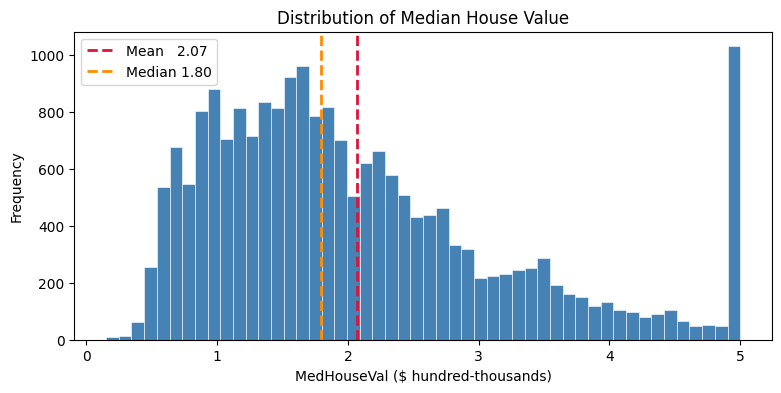

Skewness: 0.978


In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white', linewidth=0.4)

# Add mean and median lines
plt.axvline(df['MedHouseVal'].mean(),   color='crimson',    linewidth=2, linestyle='--', label=f"Mean   {df['MedHouseVal'].mean():.2f}")
plt.axvline(df['MedHouseVal'].median(), color='darkorange', linewidth=2, linestyle='--', label=f"Median {df['MedHouseVal'].median():.2f}")

plt.title('Distribution of Median House Value')
plt.xlabel('MedHouseVal ($ hundred-thousands)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f"Skewness: {df['MedHouseVal'].skew():.3f}")

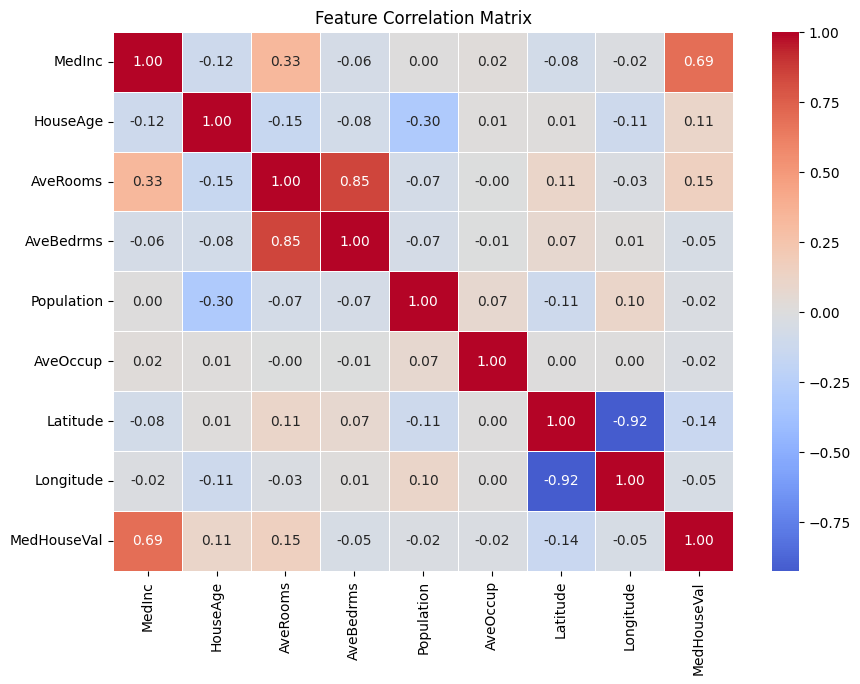

In [6]:
import seaborn as sns

plt.figure(figsize=(10, 7))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Feature Correlation Matrix')
plt.show()

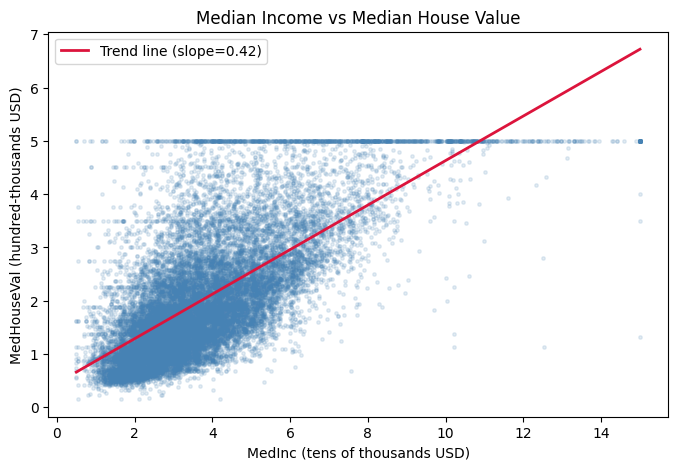

Pearson r: 0.6881


In [7]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['MedInc'],
    df['MedHouseVal'],
    alpha=0.15,
    s=6,
    color='steelblue'
)

# Add a trend line
m, b = np.polyfit(df['MedInc'], df['MedHouseVal'], 1)
x_line = np.linspace(df['MedInc'].min(), df['MedInc'].max(), 200)
plt.plot(x_line, m*x_line + b, color='crimson', linewidth=2, label=f'Trend line (slope={m:.2f})')

plt.title('Median Income vs Median House Value')
plt.xlabel('MedInc (tens of thousands USD)')
plt.ylabel('MedHouseVal (hundred-thousands USD)')
plt.legend()
plt.show()

print(f"Pearson r: {df['MedInc'].corr(df['MedHouseVal']):.4f}")

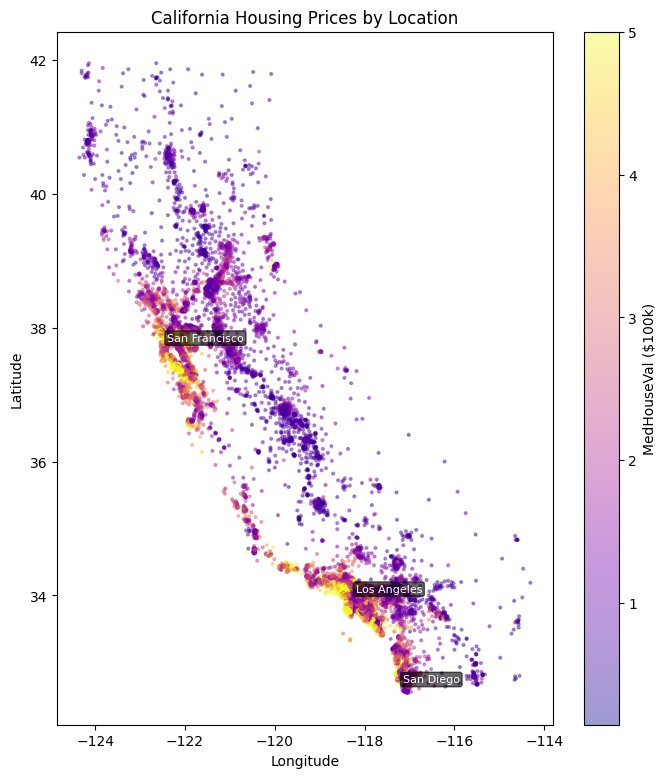

In [8]:
plt.figure(figsize=(8, 9))

scatter = plt.scatter(
    df['Longitude'],     # x axis → east/west
    df['Latitude'],      # y axis → north/south
    c=df['MedHouseVal'], # colour = house price
    cmap='plasma',       # colour scale (purple=cheap, yellow=expensive)
    alpha=0.4,
    s=4
)

plt.colorbar(scatter, label='MedHouseVal ($100k)')
plt.title('California Housing Prices by Location')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Label key cities
cities = {
    'San Francisco': (-122.4, 37.8),
    'Los Angeles':   (-118.2, 34.05),
    'San Diego':     (-117.15, 32.7)
}
for city, (lon, lat) in cities.items():
    plt.annotate(city, xy=(lon, lat), fontsize=8, color='white',
                 bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.6))

plt.show()

In [9]:
# Remove extreme outliers using the 99th percentile cap
cols_to_cap = ['AveRooms', 'AveBedrms', 'AveOccup', 'Population']

for col in cols_to_cap:
    cap = df[col].quantile(0.99)  # top 1% threshold
    df = df[df[col] < cap]

print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (19824, 9)


In [10]:
from sklearn.model_selection import train_test_split

# Separate features from target
X = df.drop(columns=['MedHouseVal'])  # everything except target
y = df['MedHouseVal']                 # just the target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% goes to test
    random_state=42   # so we get the same split every time
)

print("Training size:", X_train.shape)
print("Test size:    ", X_test.shape)

Training size: (15859, 8)
Test size:     (3965, 8)


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data only, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Sample scaled values (first row):")
print(X_train_scaled[0].round(3))

Sample scaled values (first row):
[ 0.139  1.854  0.075 -0.402 -1.177 -0.626  0.998 -1.287]


In [12]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train it — this is where the learning happens
model.fit(X_train_scaled, y_train)

print("Model trained ✅")

# See what weights the model learned
feature_names = X.columns
weights = model.coef_

print("\nFeature weights:")
for name, weight in zip(feature_names, weights):
    print(f"  {name:15} → {weight:.4f}")

print(f"\nBias (intercept): {model.intercept_:.4f}")

Model trained ✅

Feature weights:
  MedInc          → 0.8206
  HouseAge        → 0.1406
  AveRooms        → -0.1220
  AveBedrms       → 0.1172
  Population      → 0.0505
  AveOccup        → -0.2756
  Latitude        → -0.9358
  Longitude       → -0.8619

Bias (intercept): 2.0775


In [13]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Make predictions on test data
y_pred = model.predict(X_test_scaled)

# Calculate accuracy metrics
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:.4f}  (${rmse*100:.0f}k average error)")
print(f"R²   : {r2:.4f}   ({r2*100:.1f}% of variance explained)")

RMSE : 0.6757  ($68k average error)
R²   : 0.6691   (66.9% of variance explained)


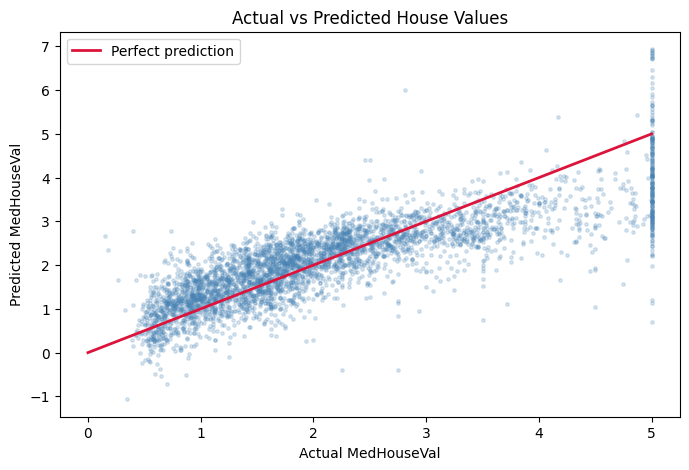

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.2, s=6, color='steelblue')
plt.plot([0, 5], [0, 5], color='crimson', lw=2, label='Perfect prediction')
plt.title('Actual vs Predicted House Values')
plt.xlabel('Actual MedHouseVal')
plt.ylabel('Predicted MedHouseVal')
plt.legend()
plt.show()

In [15]:
from sklearn.ensemble import RandomForestRegressor

# Create the model
rf_model = RandomForestRegressor(
    n_estimators=100,  # 100 trees
    random_state=42
)

# Train it
rf_model.fit(X_train_scaled, y_train)

# Evaluate
y_pred_rf = rf_model.predict(X_test_scaled)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"Random Forest Results:")
print(f"RMSE : {rmse_rf:.4f}  (${rmse_rf*100:.0f}k average error)")
print(f"R²   : {r2_rf:.4f}   ({r2_rf*100:.1f}% of variance explained)")

print(f"\nLinear Regression Results (for comparison):")
print(f"RMSE : {rmse:.4f}  (${rmse*100:.0f}k average error)")
print(f"R²   : {r2:.4f}   ({r2*100:.1f}% of variance explained)")

Random Forest Results:
RMSE : 0.5019  ($50k average error)
R²   : 0.8174   (81.7% of variance explained)

Linear Regression Results (for comparison):
RMSE : 0.6757  ($68k average error)
R²   : 0.6691   (66.9% of variance explained)


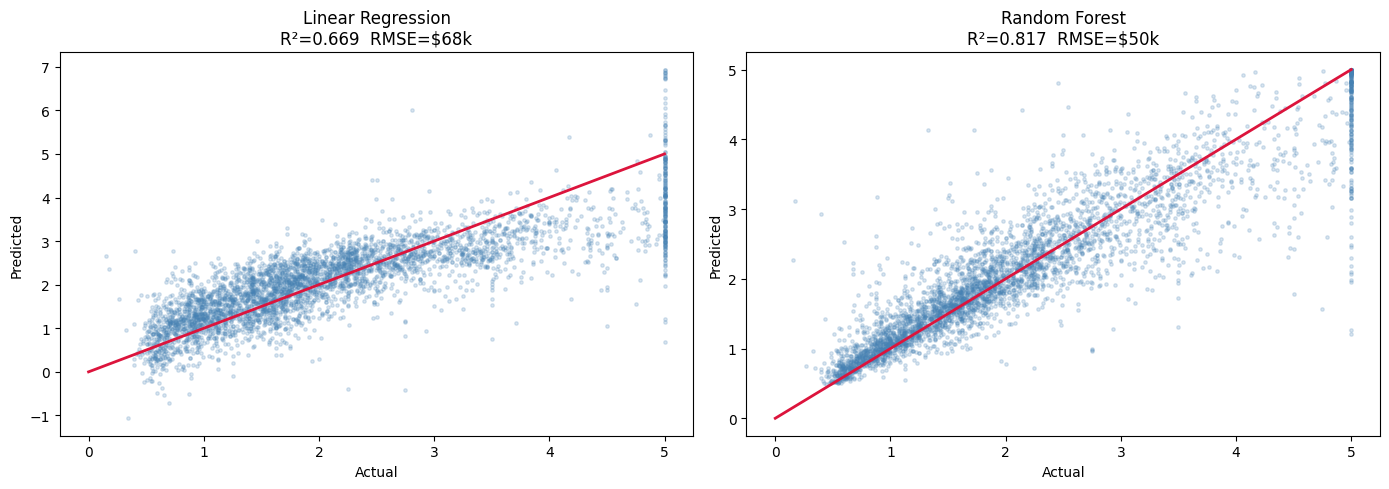

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression
axes[0].scatter(y_test, y_pred, alpha=0.2, s=6, color='steelblue')
axes[0].plot([0, 5], [0, 5], color='crimson', lw=2)
axes[0].set_title(f'Linear Regression\nR²={r2:.3f}  RMSE=${rmse*100:.0f}k')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

# Random Forest
axes[1].scatter(y_test, y_pred_rf, alpha=0.2, s=6, color='steelblue')
axes[1].plot([0, 5], [0, 5], color='crimson', lw=2)
axes[1].set_title(f'Random Forest\nR²={r2_rf:.3f}  RMSE=${rmse_rf*100:.0f}k')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

plt.tight_layout()
plt.show()

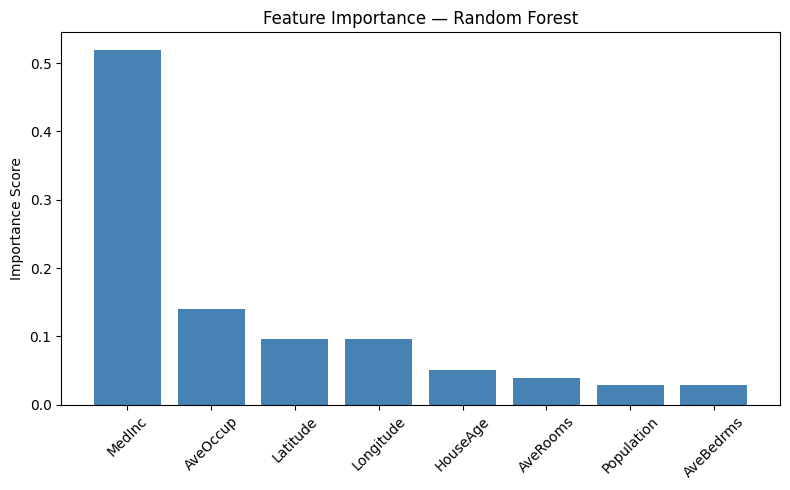

In [17]:
# Feature importance
importances = rf_model.feature_importances_
features = X.columns

# Sort by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
plt.bar(range(len(features)), importances[indices], color='steelblue')
plt.xticks(range(len(features)), [features[i] for i in indices], rotation=45)
plt.title('Feature Importance — Random Forest')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()